# Alzheimer's Disease Prediction - Exploratory Data Analysis

This notebook explores the OASIS Longitudinal dataset to understand 
the data before building a machine learning model.

Dataset: OASIS Longitudinal MRI Data
Target: Group (Nondemented / Demented / Converted)
Author: Madina Alizada

In [1]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes charts appear inside the notebook
%matplotlib inline

# Clean chart styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Step 1 - Loading the Dataset

In [3]:
df = pd.read_csv("../data/oasis_longitudinal.csv")

# Show the first 5 rows
df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


## Step 2 - Dataset Overview

In [4]:
# Basic info about the dataset
print("Shape of dataset:", df.shape)
print()
print("Column names and data types:")
print(df.dtypes)
print()
print("Basic statistics:")
df.describe()

Shape of dataset: (373, 15)

Column names and data types:
Subject ID     object
MRI ID         object
Group          object
Visit           int64
MR Delay        int64
M/F            object
Hand           object
Age             int64
EDUC            int64
SES           float64
MMSE          float64
CDR           float64
eTIV            int64
nWBV          float64
ASF           float64
dtype: object

Basic statistics:


,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373.000000,373.000000,373.000000,373.000000,354.000000,371.000000,373.000000,373.000000,373.000000,373.000000
mean,1.882038,595.104558,77.013405,14.597855,2.460452,27.342318,0.290885,1488.128686,0.729568,1.195461
std,0.922843,635.485118,7.640957,2.876339,1.134005,3.683244,0.374557,176.139286,0.037135,0.138092
min,1.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1106.000000,0.644000,0.876000
25%,1.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.000000,0.700000,1.099000
50%,2.000000,552.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.000000,0.729000,1.194000
75%,2.000000,873.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1597.000000,0.756000,1.293000
max,5.000000,2639.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.000000,0.837000,1.587000


## Step 3 - Missing Values Analysis

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Percentage missing:")
print(round(df.isnull().sum() / len(df) * 100, 2))

Missing values per column:
Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
M/F            0
Hand           0
Age            0
EDUC           0
SES           19
MMSE           2
CDR            0
eTIV           0
nWBV           0
ASF            0
dtype: int64

Percentage missing:
Subject ID    0.00
MRI ID        0.00
Group         0.00
Visit         0.00
MR Delay      0.00
M/F           0.00
Hand          0.00
Age           0.00
EDUC          0.00
SES           5.09
MMSE          0.54
CDR           0.00
eTIV          0.00
nWBV          0.00
ASF           0.00
dtype: float64


## Step 4 - Target Variable Distribution

/var/folders/bl/xjql_kf56yd77r0b8wmsyv_40000gn/T/ipykernel_73694/538307150.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Group",


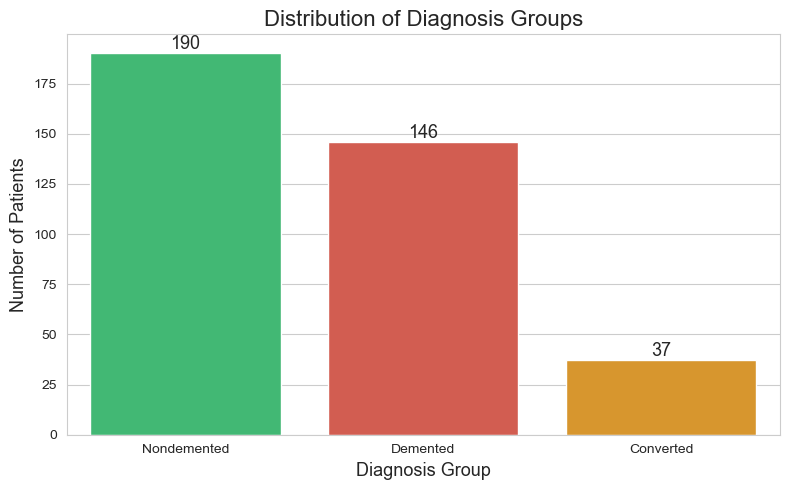

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="Group", 
                   order=["Nondemented", "Demented", "Converted"],
                   palette=["#2ecc71", "#e74c3c", "#f39c12"])

plt.title("Distribution of Diagnosis Groups", fontsize=16)
plt.xlabel("Diagnosis Group", fontsize=13)
plt.ylabel("Number of Patients", fontsize=13)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=13)

plt.tight_layout()
plt.savefig("../docs/class_distribution.png", dpi=150)
plt.show()

## Step 5 - Age Distribution by Diagnosis Group

/var/folders/bl/xjql_kf56yd77r0b8wmsyv_40000gn/T/ipykernel_73694/899006977.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Group", y="Age",


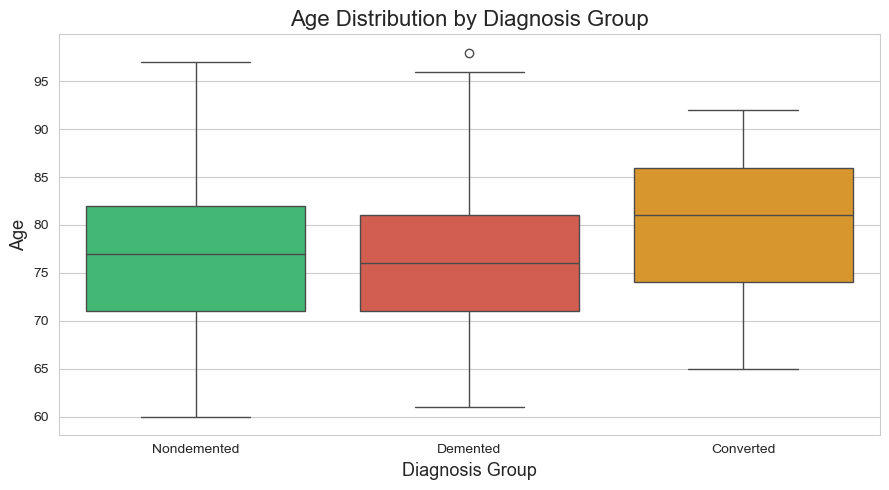

In [ ]:

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Group", y="Age",
            order=["Nondemented", "Demented", "Converted"],
            palette=["#2ecc71", "#e74c3c", "#f39c12"])

plt.title("Age Distribution by Diagnosis Group", fontsize=16)
plt.xlabel("Diagnosis Group", fontsize=13)
plt.ylabel("Age", fontsize=13)
plt.tight_layout()
plt.savefig("../docs/age_distribution.png", dpi=150)
plt.show()

Interesting finding: age alone does not strongly separate demented from nondemented patients. The boxes overlap a lot. This tells us that age is not the most powerful predictor in our model.


## Step 6 - MMSE Score by Diagnosis Group

/var/folders/bl/xjql_kf56yd77r0b8wmsyv_40000gn/T/ipykernel_73694/3232449447.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Group", y="MMSE",


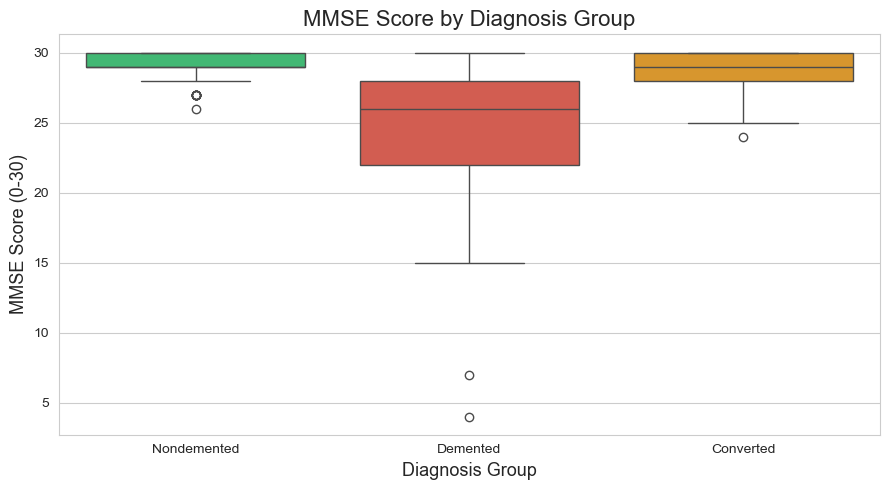

In [ ]:

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Group", y="MMSE",
            order=["Nondemented", "Demented", "Converted"],
            palette=["#2ecc71", "#e74c3c", "#f39c12"])

plt.title("MMSE Score by Diagnosis Group", fontsize=16)
plt.xlabel("Diagnosis Group", fontsize=13)
plt.ylabel("MMSE Score (0-30)", fontsize=13)
plt.tight_layout()
plt.savefig("../docs/mmse_distribution.png", dpi=150)
plt.show()

MMSE = Mini Mental State Examination.

It is a cognitive test that doctors give to patients in person. So in our chart, the Nondemented patients are scoring 29-30 almost perfectly, while Demented patients are scoring much lower: some as low as 5 or 6 which means very severe dementia.

It is basically a quick brain health checkup. Doctors use it worldwide to screen for Alzheimer's and other dementias. 

Nondemented (green) - MMSE clustered right at 29-30, almost perfect scores. Very tight box, very little variation.

Demented (red) - MMSE much lower, median around 26-27, and the box is huge meaning scores vary a lot. Some demented patients scored as low as 15. Those two dots at the bottom are severe cases scoring around 5-6.

Converted (orange) - similar to Nondemented but slightly lower, which makes sense since these patients eventually developed dementia. MMSE is going to be one of the most important features in our Random Forest model. The model will learn that low MMSE strongly predicts dementia.

## Step 7 - Brain Volume by Diagnosis Group

/var/folders/bl/xjql_kf56yd77r0b8wmsyv_40000gn/T/ipykernel_73694/1439743578.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Group", y="nWBV",


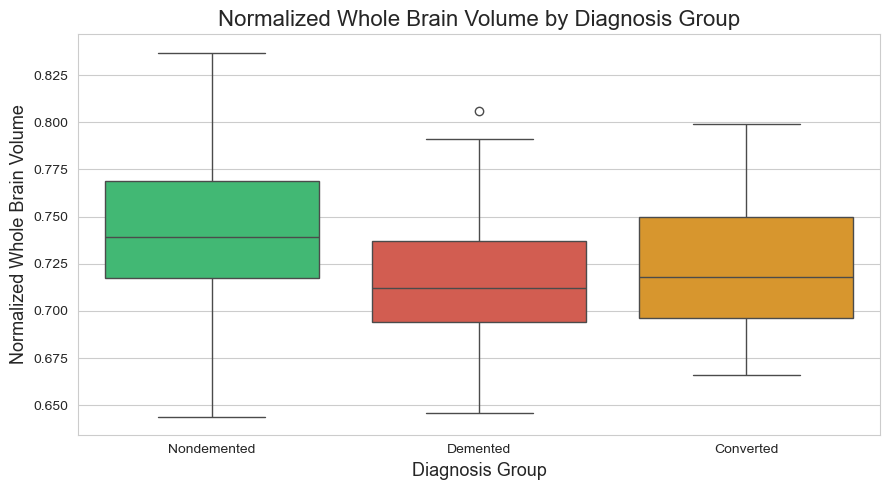

In [ ]:

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Group", y="nWBV",
            order=["Nondemented", "Demented", "Converted"],
            palette=["#2ecc71", "#e74c3c", "#f39c12"])

plt.title("Normalized Whole Brain Volume by Diagnosis Group", fontsize=16)
plt.xlabel("Diagnosis Group", fontsize=13)
plt.ylabel("Normalized Whole Brain Volume", fontsize=13)
plt.tight_layout()
plt.savefig("../docs/brain_volume_distribution.png", dpi=150)
plt.show()

Nondemented (green) - brain volume median around 0.748, higher up

Demented (red) - brain volume median around 0.714, noticeably lower

Converted (orange) - sits in between, around 0.724

Alzheimer's disease causes the brain to physically shrink over time - neurons die and brain tissue is lost. So demented patients literally have less brain volume than healthy patients.

The separation here is not as dramatic as MMSE but it is still clear. This confirms that nWBV will be an important feature in our model alongside MMSE.

## Step 8 - Correlation Heatmap

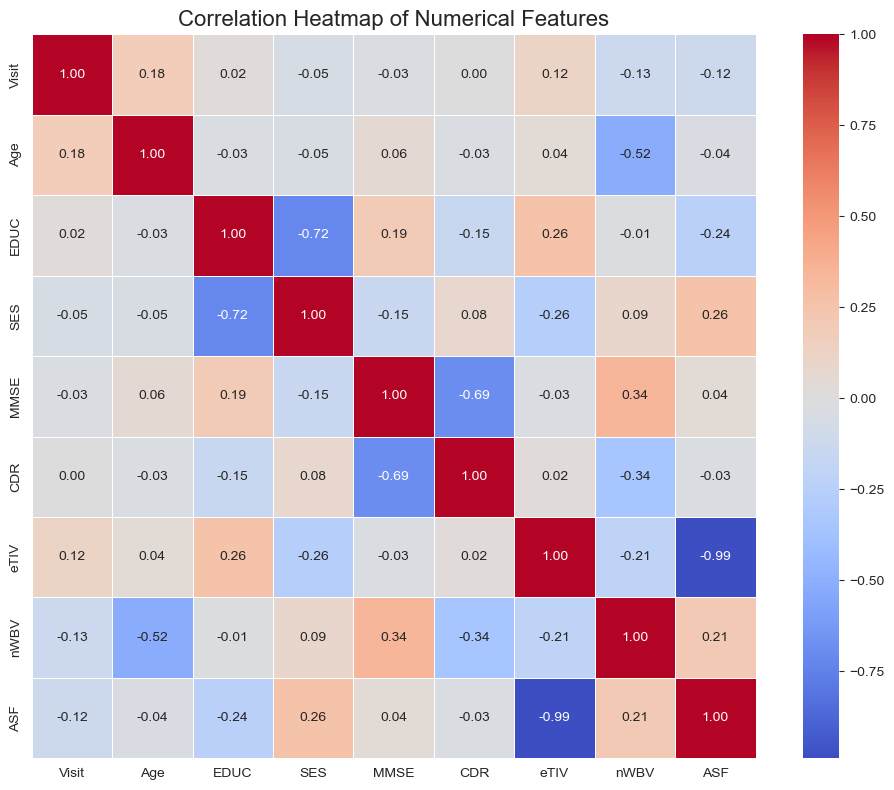

In [ ]:
# Select only numerical columns
numerical_cols = ["Visit", "Age", "EDUC", "SES", "MMSE", "CDR", "eTIV", "nWBV", "ASF"]

plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()
plt.savefig("../docs/correlation_heatmap.png", dpi=150)
plt.show()

Dark red means strong positive correlation - when one goes up, the other goes up

Dark blue means strong negative correlation -- when one goes up, the other goes down

White/light means no real relationship

The Most Important Findings:

MMSE and CDR: -0.69 - strong negative relationship. Higher MMSE means lower CDR. Makes perfect sense - better cognitive test score means lower dementia rating. This confirms these two columns measure the same thing from different angles. Good thing we dropped CDR from our features.

EDUC and SES: -0.72 - strong negative relationship. (SES is 1=wealthy, 5=poor.)So higher education correlates with higher socioeconomic status (lower number). Makes sense in real life.

eTIV and ASF: -0.99 - almost perfect negative correlation. These two are mathematically related to each other. We might only need one of them in the model.

Age and nWBV: -0.52 - as people get older their brain volume decreases. 

MMSE and nWBV: 0.34 - higher brain volume relates to better cognitive scores.

## Step 9 - MMSE Score Over Visits

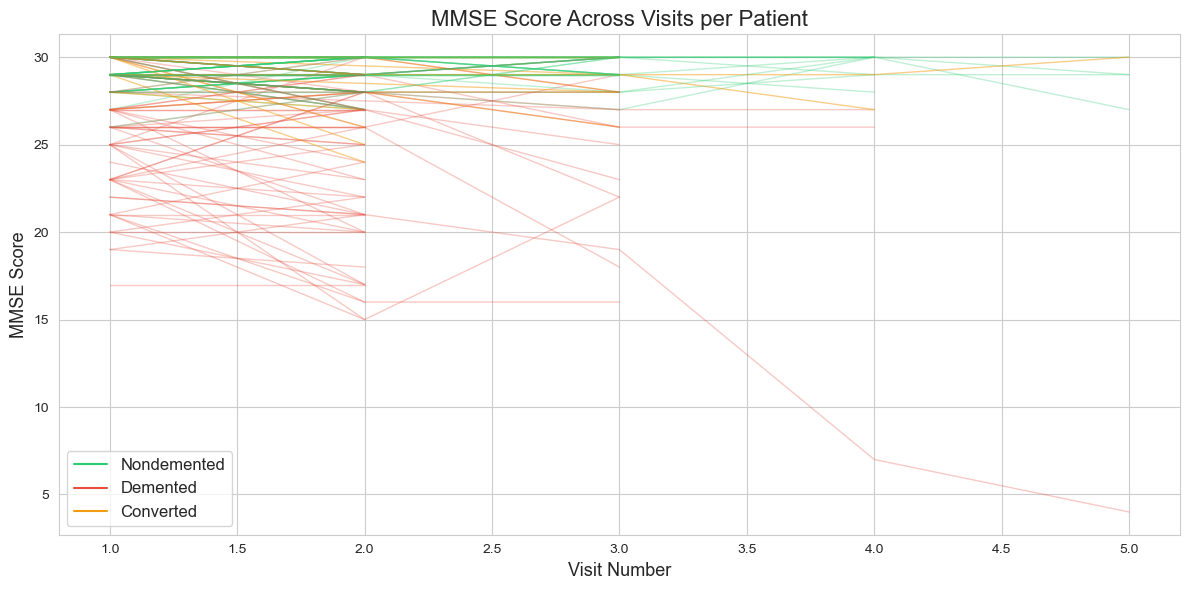

In [ ]:
# MMSE score over visits for each patient
plt.figure(figsize=(12, 6))

# Plot each patient as a separate line
for subject in df["Subject ID"].unique():
    patient_data = df[df["Subject ID"] == subject].sort_values("Visit")
    group = patient_data["Group"].iloc[0]
    
    if group == "Nondemented":
        color = "#2ecc71"
        alpha = 0.3
    elif group == "Demented":
        color = "#e74c3c"
        alpha = 0.3
    else:
        color = "#f39c12"
        alpha = 0.5
    
    plt.plot(patient_data["Visit"], 
             patient_data["MMSE"], 
             color=color, 
             alpha=alpha,
             linewidth=1)

# Add legend manually
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="#2ecc71", label="Nondemented"),
    Line2D([0], [0], color="#e74c3c", label="Demented"),
    Line2D([0], [0], color="#f39c12", label="Converted")
]
plt.legend(handles=legend_elements, fontsize=12)

plt.title("MMSE Score Across Visits per Patient", fontsize=16)
plt.xlabel("Visit Number", fontsize=13)
plt.ylabel("MMSE Score", fontsize=13)
plt.tight_layout()
plt.savefig("../docs/mmse_over_visits.png", dpi=150)
plt.show()



Each line is one real patient tracked over time.

Green lines (Nondemented) - stay flat and high near 28-30 across all visits. These patients are stable and cognitively healthy over years.

Red lines (Demented) - start lower and many decline over time. One red line that drops dramatically from visit 3 all the way down to 4 by visit 5  is a real patient whose Alzheimer's progressed severely. From a score of around 19 down to 4 - that person lost almost all cognitive function over the course of the study.

Orange lines (Converted) - start high like the green ones but some begin drifting down, which makes sense since they eventually developed dementia.